In [2]:
from itertools import product
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from scaling.visualize import visualize_train_curves, plot_line_fit, plot_isoflops
from pathlib import Path
from scaling.utils import (
    get_final_points_from_curve_set,
    fit_parametric_form,
    functional_form_chin3,
)
from sklearn.metrics import r2_score
from IPython.display import display, Math
from matplotlib.colors import TwoSlopeNorm


In [3]:
unique_col_list = ["base_N", "target_N", "tkpm", "shrink", "method"]
y_col = "Validation Loss"
x_col = "flops"

N_TEST = 1217722368
mup_test =  1.5173616409301758
warm_test = 1.496509075164795


def preprocess_warmstarting(df, y_col_to_smooth=None, smoothing_window=100):
    __df = pd.DataFrame()
    for i, x in enumerate(df.groupby(unique_col_list)):
        _df = x[1].sort_values(by="flops")
        # smooth it
        if y_col_to_smooth is not None:
            # +"_smoothed"
            _df[y_col_to_smooth] = _df[y_col_to_smooth].rolling(smoothing_window, win_type='gaussian', min_periods=1).mean(std=smoothing_window / 10)
        
        # scaling tokens and flops to the max
        max_intended_tokens = (_df.iloc[-1]["target_N"] * _df.iloc[-1]["tkpm"])
        if abs((max_intended_tokens -  _df["tokens"].max()) / _df["tokens"].max()) > 0.01:
            print("Wrong tkpm: ", x[0])
            continue
        _df["tokens"] = np.round(max_intended_tokens / _df["tokens"].max() * _df["tokens"])
        
        max_intended_flops = 6. * max_intended_tokens * _df["target_N"]
        _df["flops"] = np.round(max_intended_flops / _df["flops"].max() * _df["flops"])
        
        __df = pd.concat([__df, _df])
    
    print('Droping tkpm <= 5')    
    __df = __df[__df['tkpm'] > 5.]
    
    return __df

def preprocess_approach3_data(df, log_transform_y=True):
    N, D, G = df["target_N"].values, df["tokens"].values, df["g"].values
    y = df["Validation Loss"].values

    _df = pd.DataFrame.from_dict({
        "N": N,
        "D": D,
        "G": G,
        "Loss": y
    }).groupby(by=["N", "D", "G"]).min().reset_index()
    _df.sort_values(by=["N", "D", "G"], inplace=True)

    data_X = _df[["N", "D", "G"]].values
    data_y = _df["Loss"].values
    if log_transform_y:
        data_y = np.log(data_y)

    return data_X, data_y

def filter_pairs(df, jump_size=1):
    distinct_values = sorted(
        pd.unique(df[['base_N', 'target_N']].values.ravel())
    )
    pairs = list(zip(distinct_values[:-jump_size], distinct_values[jump_size:]))
    df_filtered = df[df[['base_N', 'target_N']].apply(tuple, axis=1).isin(pairs)]
    return df_filtered

def format_approach3_results(params):
    _a, alpha, _b, beta, _e = params

    A = np.exp(_a)
    B = np.exp(_b)
    E = np.exp(_e)
    s = f"{A:0.2f} N^({-alpha:0.3f}) + {B:0.2f} D^({-beta:0.3f}) + {E:0.3f}"
    print(s)

In [4]:
warmstarting_df = pd.read_parquet(
    "../data/warmstart_runs_flattened.parquet",
)
warmstarting_df = warmstarting_df.dropna(subset=[y_col])
warmstarting_df = preprocess_warmstarting(warmstarting_df)

Wrong tkpm:  (77124608, 1217722368, 10.0, 0.0, 'mup')
Droping tkpm <= 5


In [5]:
final_points_df = get_final_points_from_curve_set(
    warmstarting_df,
    unique_col_list,
    x_col="flops",
    y_col="Validation Loss",
    get_pareto=False,
)

final_points_df['g'] = final_points_df["target_N"] / final_points_df["base_N"]

In [6]:
warm_df = final_points_df[(final_points_df['method']=='paws') & (final_points_df['shrinking']==0.4)]

Target N:  77124608
Target N:  134561280
Target N:  287183360


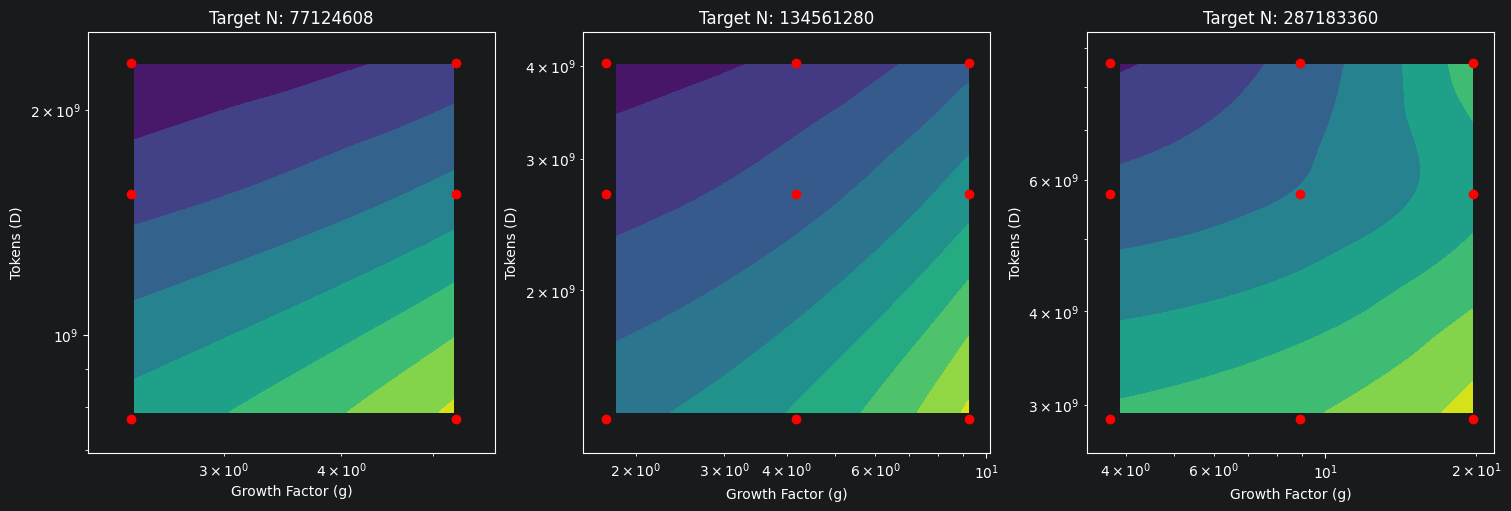

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

target_models= sorted(warm_df["target_N"].unique())[1:-1]

fig, axes = plt.subplots(1, len(target_models), figsize=(5 * len(target_models), 5), layout='constrained')

for idx, target_N in enumerate(target_models):
    ax = axes[idx]
    print("Target N: ", target_N)
    subset_df = warm_df[warm_df["target_N"] == target_N]
    # plot g vs D with a contour plot
    # your data (example)
    data_X, data_y = preprocess_approach3_data(subset_df)
    x = data_X[:, 2]
    y = data_X[:, 1]
    z = np.exp(data_y)

    # 1. Create grid
    xi = np.linspace(x.min()*0.9, x.max()*1.1, 100)
    yi = np.linspace(y.min()*0.9, y.max()*1.1, 100)
    Xi, Yi = np.meshgrid(xi, yi)

    # 2. Interpolate z onto grid
    Zi = griddata((x, y), z, (Xi, Yi), method='cubic')

    # 3. Plot contour
    ax.contourf(Xi, Yi, Zi)
    ax.scatter(x, y, color="red")  # optional: show original points
    # y axis log scale
    ax.loglog()
    ax.set_xlabel("Growth Factor (g)")
    ax.set_ylabel("Tokens (D)")
    ax.set_title(f"Target N: {target_N}")



In [11]:
target_N

[np.int64(32270848),
 np.int64(77124608),
 np.int64(134561280),
 np.int64(287183360),
 np.int64(610488320)]

In [5]:
def fit_chin3(data_X, data_y, dense_grid=False):
    if dense_grid:
        initialization = list(product(
            np.arange(0, 25, 1),
            np.arange(0, 2, 0.1),
            np.arange(0, 25, 1),
            np.arange(0, 2, 0.1),
            np.arange(-1, 1, 0.1)
        ))
    else:
        initialization = list(product(
            np.arange(0, 25, 5),
            np.arange(0, 2, 0.5),
            np.arange(0, 25, 5),
            np.arange(0, 2, 0.5),
            np.arange(-1, 1, 0.5)
        ))
    best_params, best_loss, df = fit_parametric_form(
        functional_form_chin3,
        data_X[:,:2],
        data_y,
        initialization
    )
    y_true = data_y
    y_pred = functional_form_chin3(data_X[:,:2], best_params)
    r2_log = r2_score(y_true, y_pred)
    r2 = r2_score(np.exp(y_true), np.exp(y_pred))



    test_point = np.array([[N_TEST, 10 * N_TEST]])
    test_prediction = float(np.exp(functional_form_chin3(test_point, best_params))[0])

    print("Fit")
    format_approach3_results(best_params)
    print("Top fits")
    print(df.head())
    print("Quality of Fit")
    print("Test prediction: ", test_prediction, " | muP true value: ", mup_test, " | warm true value: ", warm_test)
    print("Log scaled R2: ", r2_log)
    print("R2: ", r2)

    return best_params

In [38]:
mup_df = final_points_df[final_points_df['method']=='mup']
mup_jump_df = filter_pairs(mup_df, jump_size=1)
mup_data_X, mup_data_y = preprocess_approach3_data(mup_jump_df)
mup_params = fit_chin3(mup_data_X, mup_data_y)

Fit
186341.06 N^(-0.767) + 5.79 D^(-0.068) + 0.402
Top fits
                 A     alpha         b      beta         e      loss
7     1.863411e+05  0.767018  5.790254  0.067851  0.402404  0.000014
6     1.399447e+05  0.749444  5.910755  0.071572  0.474772  0.000014
642   2.227464e+04  0.637134  7.613355  0.100295  0.826008  0.000015
1040  3.051407e+06  0.934089  6.353131  0.081942  0.688042  0.000016
1157  2.566823e+06  0.923536  6.736271  0.088829  0.779195  0.000016
Quality of Fit
Test prediction:  1.6202104658945227  | muP true value:  1.5173616409301758  | warm true value:  1.496509075164795
Log scaled R2:  0.9988150622778795
R2:  0.9988881398751035


In [39]:
warm_df = final_points_df[(final_points_df['method']=='paws') & (final_points_df['shrinking']==0.4)]
warm_jump_df = filter_pairs(warm_df, jump_size=1)
warm_data_X, warm_data_y = preprocess_approach3_data(warm_jump_df)
warm_params = fit_chin3(warm_data_X, warm_data_y)

Fit
814.69 N^(-0.423) + 130.04 D^(-0.295) + 1.305
Top fits
                A     alpha           b      beta         e      loss
22     814.685846  0.422954  130.039008  0.295363  1.304693  0.000004
420    747.443638  0.417364  150.234601  0.303602  1.306310  0.000004
401    246.489425  0.345195   64.539075  0.253878  1.167838  0.000005
802  22601.104810  0.632057   27.338606  0.199988  1.296245  0.000007
641  17812.093960  0.617445   10.910485  0.138611  1.108360  0.000007
Quality of Fit
Test prediction:  1.5582185044022452  | muP true value:  1.5173616409301758  | warm true value:  1.496509075164795
Log scaled R2:  0.9998376216786947
R2:  0.9998512352432287


[]

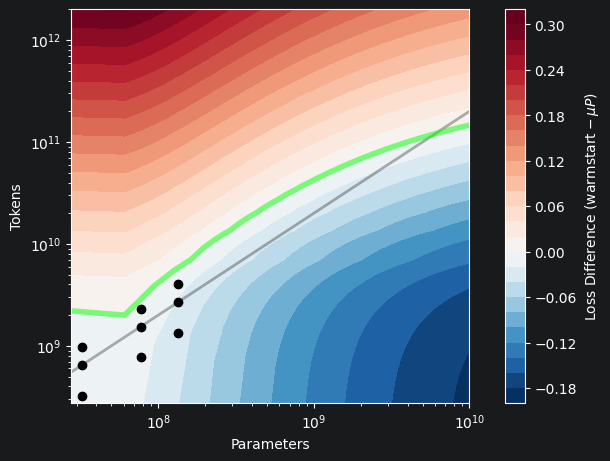

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5), layout='constrained')

D_contour = np.linspace(final_points_df["tokens"].min()*0.85, 2e12, 300)
N_contour = np.linspace(final_points_df["target_N"].min()*0.85, 1e10, 300)

N_cg , D_cg = np.meshgrid(N_contour, D_contour)
L_cg = np.zeros_like(N_cg)



for params, factor in [(mup_params, -1), (warm_params, 1)]:
    _L_cg = np.exp(functional_form_chin3(
            np.column_stack((
                N_cg.reshape(-1),
                D_cg.reshape(-1)
            )),
            params
        ))
    L_cg += _L_cg.reshape(N_cg.shape) * factor

norm = TwoSlopeNorm(vmin=L_cg.min(), vcenter=0, vmax=L_cg.max())
cs = ax.contourf(N_cg, D_cg, L_cg, levels=30, cmap="RdBu_r", norm=norm, zorder=-1)
ax.plot(N_contour, N_contour*20, color='black', linewidth=2, zorder=-1, alpha=0.3)
lime_N_D = ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='lime', linewidths=4, zorder=1, alpha=0.5)
# ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='green', linewidths=1.5, zorder=1)

ax.scatter(warm_data_X[:,0], warm_data_X[:,1], color="black")

fig.colorbar(cs, ax=ax, label=r'Loss Difference ($\text{warmstart} - \mu P$)')
ax.set_xlabel("Parameters")
ax.set_ylabel("Tokens")
ax.loglog()

In [41]:
mup_df = final_points_df[final_points_df['method']=='mup']
mup_jump_df = filter_pairs(mup_df, jump_size=2)
mup_data_X, mup_data_y = preprocess_approach3_data(mup_jump_df)
mup_params = fit_chin3(mup_data_X, mup_data_y)

Fit
11.41 N^(-0.114) + 137.35 D^(-0.274) + 0.123
Top fits
              A     alpha           b      beta         e      loss
36    11.412062  0.114243  137.354987  0.274127  0.123082  0.000018
22    11.686208  0.116505  295.112073  0.316422  0.196960  0.000019
2     23.778883  0.173257   34.504878  0.196283  0.414259  0.000023
1     50.806328  0.230468   72.495207  0.238546  0.735494  0.000025
420  109.256985  0.282618  149.800987  0.279074  0.918749  0.000027
Quality of Fit
Test prediction:  1.4048963437423325  | muP true value:  1.5173616409301758  | warm true value:  1.496509075164795
Log scaled R2:  0.9983170682794408
R2:  0.9982825851749539


In [42]:
warm_df = final_points_df[(final_points_df['method']=='paws') & (final_points_df['shrinking']==0.4)]
warm_jump_df = filter_pairs(warm_df, jump_size=2)
warm_data_X, warm_data_y = preprocess_approach3_data(warm_jump_df)
warm_params = fit_chin3(warm_data_X, warm_data_y)

Fit
11.45 N^(-0.112) + 44.29 D^(-0.213) + 0.000
Top fits
             A     alpha           b      beta             e      loss
81   11.451257  0.112480   44.287862  0.213431  1.729066e-11  0.000015
672  11.422702  0.112213   45.540202  0.215098  3.248908e-05  0.000015
37   13.435376  0.127857   45.527106  0.215030  1.701234e-01  0.000016
22   13.353502  0.127257  130.184248  0.274431  2.534755e-01  0.000018
20   12.722932  0.122887  163.345450  0.286606  2.239043e-01  0.000019
Quality of Fit
Test prediction:  1.4003994881105224  | muP true value:  1.5173616409301758  | warm true value:  1.496509075164795
Log scaled R2:  0.9983283545108984
R2:  0.9983218736100015


[]

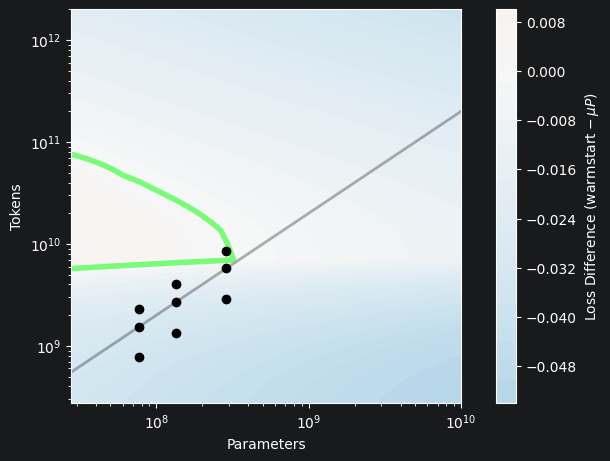

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5), layout='constrained')

D_contour = np.linspace(final_points_df["tokens"].min()*0.85, 2e12, 300)
N_contour = np.linspace(final_points_df["target_N"].min()*0.85, 1e10, 300)

N_cg , D_cg = np.meshgrid(N_contour, D_contour)
L_cg = np.zeros_like(N_cg)



for params, factor in [(mup_params, -1), (warm_params, 1)]:
    _L_cg = np.exp(functional_form_chin3(
            np.column_stack((
                N_cg.reshape(-1),
                D_cg.reshape(-1)
            )),
            params
        ))
    L_cg += _L_cg.reshape(N_cg.shape) * factor


cs = ax.contourf(N_cg, D_cg, L_cg, levels=30, cmap="RdBu_r", norm=norm, zorder=-1)
ax.plot(N_contour, N_contour*20, color='black', linewidth=2, zorder=-1, alpha=0.3)
lime_N_D = ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='lime', linewidths=4, zorder=1, alpha=0.5)
# ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='green', linewidths=1.5, zorder=1)

ax.scatter(warm_data_X[:,0], warm_data_X[:,1], color="black")

fig.colorbar(cs, ax=ax, label=r'Loss Difference ($\text{warmstart} - \mu P$)')
ax.set_xlabel("Parameters")
ax.set_ylabel("Tokens")
ax.loglog()

In [46]:
mup_df = final_points_df[final_points_df['method']=='mup']
mup_jump_df = filter_pairs(mup_df, jump_size=3)
mup_data_X, mup_data_y = preprocess_approach3_data(mup_jump_df)
mup_params = fit_chin3(mup_data_X, mup_data_y)

Fit
93819724402543634347241268279946724684144951770421925566744176166994558335806812654594756369115512832.00 N^(-12.517) + 4978.23 D^(-0.455) + 1.463
Top fits
                A      alpha             b      beta         e      loss
21  9.381972e+100  12.517424  4.978234e+03  0.455058  1.463338  0.000039
41   9.857711e+67   8.459431  2.260433e+04  0.532485  1.498424  0.000039
42   1.158860e+55   6.868671  2.258532e+04  0.532406  1.497681  0.000040
6   4.016914e+307  37.944597  1.521576e+01  0.126975  0.778696  0.000047
32   7.528180e+34   4.383266  3.405718e+06  0.777601  1.548460  0.000053
Quality of Fit
Test prediction:  1.5914412610677697  | muP true value:  1.5173616409301758  | warm true value:  1.496509075164795
Log scaled R2:  0.9612708142729299
R2:  0.962364169127543


In [47]:
warm_df = final_points_df[(final_points_df['method']=='paws') & (final_points_df['shrinking']==0.4)]
warm_jump_df = filter_pairs(warm_df, jump_size=3)
warm_data_X, warm_data_y = preprocess_approach3_data(warm_jump_df)
warm_params = fit_chin3(warm_data_X, warm_data_y)

Fit
444059558.68 N^(-1.131) + 6644.44 D^(-0.470) + 1.355
Top fits
                 A     alpha             b      beta         e      loss
1313  4.440596e+08  1.130759   6644.442297  0.469861  1.355345  0.000001
800   2.270187e+04  0.576906   6601.386310  0.469530  1.176755  0.000001
1042  3.261898e+06  0.858345   6767.005548  0.470796  1.297715  0.000001
400   4.120320e+02  0.338816   6996.794807  0.472486  0.916462  0.000001
996   2.858068e+06  0.850906  10429.360757  0.492721  1.305398  0.000001
Quality of Fit
Test prediction:  1.500237891682952  | muP true value:  1.5173616409301758  | warm true value:  1.496509075164795
Log scaled R2:  0.9999243600587582
R2:  0.999925114822249


[]

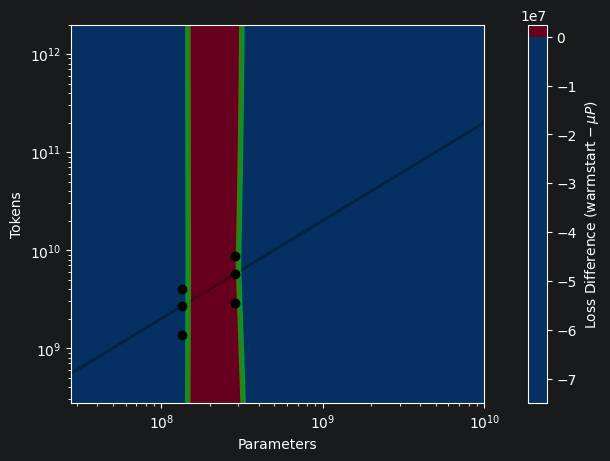

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5), layout='constrained')

D_contour = np.linspace(final_points_df["tokens"].min()*0.85, 2e12, 300)
N_contour = np.linspace(final_points_df["target_N"].min()*0.85, 1e10, 300)

N_cg , D_cg = np.meshgrid(N_contour, D_contour)
L_cg = np.zeros_like(N_cg)



for params, factor in [(mup_params, -1), (warm_params, 1)]:
    _L_cg = np.exp(functional_form_chin3(
            np.column_stack((
                N_cg.reshape(-1),
                D_cg.reshape(-1)
            )),
            params
        ))
    L_cg += _L_cg.reshape(N_cg.shape) * factor


cs = ax.contourf(N_cg, D_cg, L_cg, levels=30, cmap="RdBu_r", norm=norm, zorder=-1)
ax.plot(N_contour, N_contour*20, color='black', linewidth=2, zorder=-1, alpha=0.3)
lime_N_D = ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='lime', linewidths=4, zorder=1, alpha=0.5)
# ax.contour(N_cg, D_cg, L_cg, levels=[0], colors='green', linewidths=1.5, zorder=1)

ax.scatter(warm_data_X[:,0], warm_data_X[:,1], color="black")

fig.colorbar(cs, ax=ax, label=r'Loss Difference ($\text{warmstart} - \mu P$)')
ax.set_xlabel("Parameters")
ax.set_ylabel("Tokens")
ax.loglog()

In [44]:
# Set up the fitting of the data like in the old paper
# Plot it
# Try the searchspaces of the other papers


In [45]:
# Create visualizations for custom loss function
# Try fitting and look at R2 and extrapolation

In [ ]:
# Misfitting
LBFGS with different tolerrances

a_vals = np.arange(0, 25, 1)
b_vals = np.arange(0, 25, 1)
e_vals = np.arange(-1, 1, 0.1)
alpha_vals = np.arange(0, 2, 0.1)
beta_vals = np.arange(0, 2, 0.1)

a_vals = np.arange(0, 25, 5)
b_vals = np.arange(0, 25, 5)
e_vals = np.arange(-1, 1, 0.5)
alpha_vals = np.arange(0, 2, 0.5)
beta_vals = np.arange(0, 2, 0.5)


# Gemstone
method="L-BFGS-B"

for _ in range(num_parameters):
        param_search_array.append(np.arange(0, 2.5, 0.5))  # exp, 5 possible values
    for _ in range(num_parameters):
        param_search_array.append(np.arange(0, 30, 5))  # coefficient, 6 values
    param_search_array.append(np.arange(-1, 1.5, 0.5))  # error, 5 values



# mine

np.linspace(0, 15, 5),  # a
np.linspace(0., 1., 5),  # alpha
np.linspace(0, 15, 5),  # b
np.linspace(0., 1., 5),  # beta
np.linspace(0., 1., 5),  # e


# Farseer

torch.optim.LBFGS([params],
lr=1e-1,
history_size=10,
max_iter=20,
line_search_fn="strong_wolfe")

for a in np.linspace(0, 25, 5):
        for b in np.linspace(0, 25, 5):
            for e in np.linspace(-1, 1, 4):
                for alpha in np.linspace(0, 2, 4):